In [19]:
import numpy as np 
import scipy.signal as sig
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
from IPython.display import HTML

In [103]:
R = 47
R0 = 157
V_constant = 0.25
k=6
C = 1

t0 = 0
tmax = 500
h = 0.125e-3
N = int((tmax - t0) / h)
x0 = np.array([0,0,R/R0 * V_constant])


In [104]:
def f(t,V,Rv):
    ftV = np.array([V[1],V[2],-R/Rv * V[2]-V[1] - R/R0*V_constant])
    if V[0] < 0:
        ftV[2] -= k *V[0]        
    return ftV

def rk4(f,Rv):
    """
    A 4-stage Runge-Kutta method for a system of first order ODEs 
      y' = f(t,y) for t in [t0, tmax] using N steps

    Parameters
    ----------
    f    : function f(t,y) returns an array of size m
    t0   : initial time
    tmax : final time
    N    : number of time steps
    y0   : initial value as an array of size m

    Returns
    -------
    t    : an array of size N+1
    y    : a matrix of size N+1 by m
    
    (Frances Kuo 25 March 2023)
    """
    m = np.size(x0)                   # m is the dimension of the system
    h = (tmax - t0) / N            # h is the step size
    t = np.arange(t0, tmax + h/2, h)  # t is an array of size N+1
    y = np.zeros((N+1, m))            # y is a matrix of size N+1 by m

    y[0,:] = x0                    # y0 is an array of size N+1
    for n in range(N):             # f returns an array of size m
        k1 = f(t[n],       y[n,:]             ,Rv)
        k2 = f(t[n] + h/2, y[n,:] + (h/2) * k1,Rv)
        k3 = f(t[n] + h/2, y[n,:] + (h/2) * k2,Rv)
        k4 = f(t[n] + h,   y[n,:] +     h * k3,Rv)
        y[n+1,:] = y[n,:] + (h/6) * ( k1 + 2*k2 + 2*k3 + k4 )  # RK4
    t_real = t * R * C * 1e-3
    return t_real, y

800001


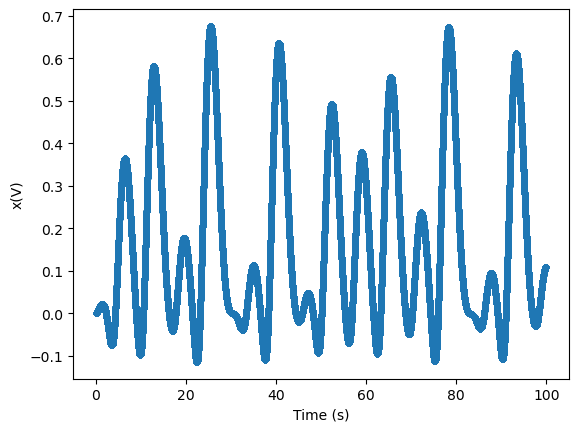

In [28]:
t,x = rk4(f,80)

print(len(t))

plt.scatter(t,x[:,0],marker='.')
plt.xlabel('Time (s)')
plt.ylabel("x(V)")
plt.show()

In [48]:
Rv_range = np.linspace(50,130,500)

Rv_values = []
peaks_voltages = []

for i in Rv_range:
    t,x = rk4(f,i)
    voltage = x[:,0]
    peaks, _ = sig.find_peaks(voltage)
    peak_values = voltage[peaks]

    Rv_values.extend([i]*len(peak_values))
    peaks_voltages.extend(peak_values)

plt.scatter(Rv_values,peaks_voltages,marker='.',color='lightgrey')
plt.xlabel(r'$R_v(k\Omega)$')
plt.ylabel("x(V)")

KeyboardInterrupt: 

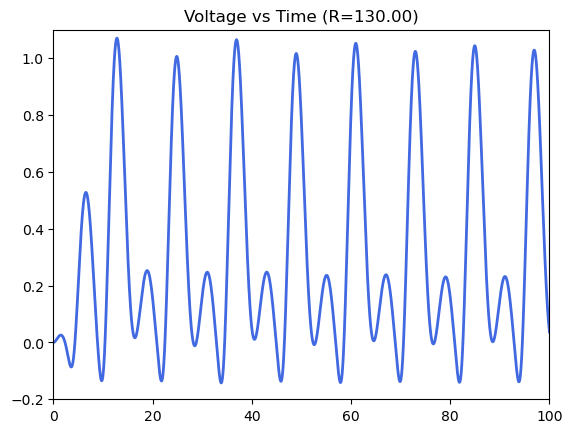

In [ ]:
fig, ax = plt.subplots()

ax.set_xlim(t0, tmax)
ax.set_ylim(-0.2, 1.1)

ln, = ax.plot([],[],lw=2,color='royalblue')
title = ax.set_title("")

def init():
    ln.set_data([],[])
    return ln,

def update(frame):
    Rv = Rv_values[frame]

    t,x = rk4(f,Rv)
    voltages = x[:,0]
    ln.set_data(t, voltages)
    ax.set_title(f"Voltage vs Time (R={Rv:.2f})")
    return ln,

Rv_values = np.linspace(50, 130, 100)

ani = FuncAnimation(fig, update, frames=len(Rv_values),init_func=init,blit=True,interval=200)
HTML(ani.to_jshtml())
ani.save("../Model_Figures/voltage_animation.gif", writer="pillow", fps=10)

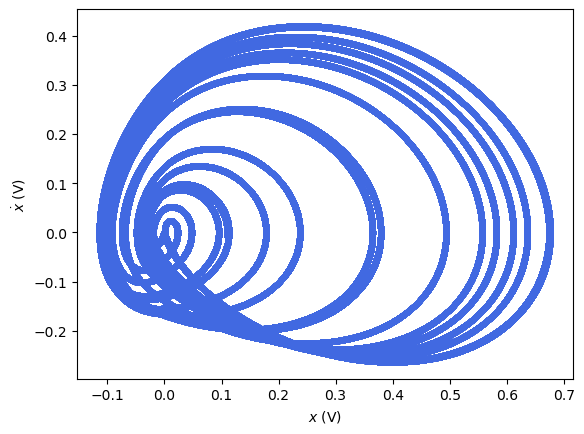

In [ ]:
t,x = rk4(f,80)

plt.scatter(x[:,0],x[:,1],marker='.',color='royalblue')
plt.xlabel(r'$x$ (V)')
plt.ylabel(r"$\dot{x}$ (V)")
plt.savefig('../Model_Figures/phase_plot_80k',bbox_inches = 'tight')
plt.show()

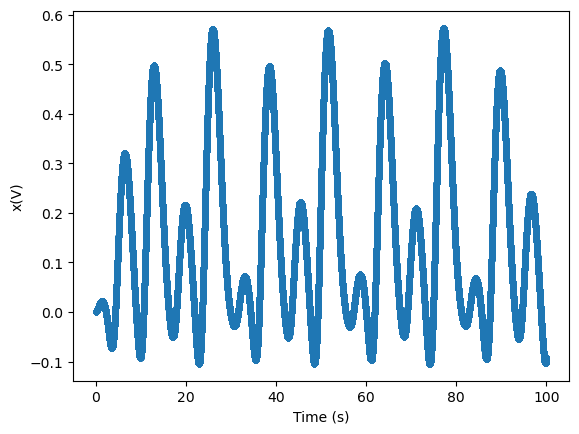

In [59]:
t, x = rk4(f,70)
result = x[:,0]

plt.scatter(t,result,marker='.')
plt.xlabel('Time (s)')
plt.ylabel("x(V)")
plt.show()

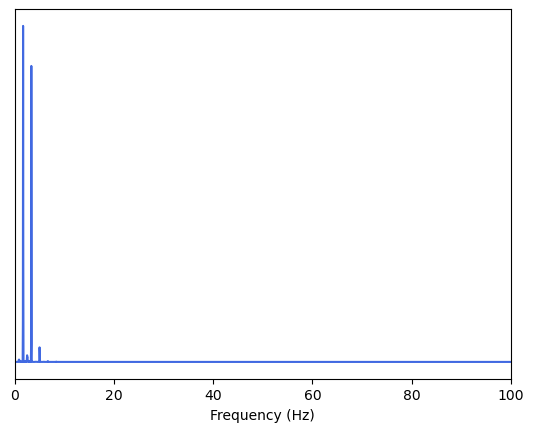

In [ ]:
## FFT code
downsample = 1
t, x = rk4(f,70)
t = t[::downsample]
result = x[:,0]
result = result[::downsample]

result = result - np.mean(result)

dt = t[1] - t[0]
fs = 1/dt

window = np.hamming(len(result))

fft = np.fft.rfft(window*result)

fftfreq = np.fft.rfftfreq(len(result), dt)

plt.plot(fftfreq,np.abs(fft)**2,c='royalblue')

In [1]:
plt.plot(fftfreq,np.abs(fft)**2,c='royalblue')
plt.xlim(0,20)
plt.xlabel('Frequency (Hz)')
plt.yticks([])

plt.show()

NameError: name 'plt' is not defined